# Assignment 3 — Task 3 (combined)
## Cosmetics/Beauty Review Classification — `is_a_buyer`

#### Group Members
1. Vo Ngoc Dung — S4124370
2. Tang Hoang Ha — S4147768
3. Nguyen Anh Duc — S4136756
4. Nguyen Quoc Trong Nghia — S3343711

This notebook combines Q1 and Q2 of Task 3 in a single, linear, easy-to-follow flow.

- **Part 1 — Q1.** Compare three feature representations (Count BoW, Unweighted FastText, TF-IDF-Weighted FastText) using three classifiers (Logistic Regression, Decision Tree, Random Forest), with review text only.
- **Part 2 — Q2.** Re-run the same 9 (representation × model) combinations after adding review title (Q2a) and product metadata (Q2b), then compare lift.

Same evaluation protocol throughout: **5-fold StratifiedKFold (seed=42)**, five metrics (**Accuracy, macro-Precision, macro-Recall, macro-F1, ROC-AUC**).

---
# Part 1 — Q1: Which language model performs best?

## Step 1 · Imports and data loading

In [1]:
# Standard libraries
import os, re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sparse matrix utilities (for the bag-of-words count vectors)
from scipy.sparse import csr_matrix, hstack as sp_hstack

# Models — three classifiers
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier

# Evaluation
from sklearn.model_selection         import StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing           import StandardScaler, OneHotEncoder

# Pretrained word embeddings — same FastText model used in Task 2
import gensim.downloader as gensim_api

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Paths to Task 1 / Task 2 outputs
PROCESSED_CSV     = "processed.csv"
VOCAB_FILE        = "vocab.txt"
STOPWORDS_FILE    = "stopwords_en.txt"
COUNT_VECTOR_FILE = "count_vectors.txt"
UNWEIGHTED_FILE   = "unweighted_vectors.txt"
WEIGHTED_FILE     = "weighted_vectors.txt"

# Load processed reviews and the binary label
df = pd.read_csv(PROCESSED_CSV)
df['review_text']  = df['review_text'].fillna('').astype(str)
y = df['is_a_buyer'].astype(str).str.lower().map({'true': 1, 'false': 0}).astype(int).to_numpy()

print(f"Reviews: {len(df):,}")
print(f"Class balance: buyers = {y.mean():.3f}, non-buyers = {1 - y.mean():.3f}")

Reviews: 60,407
Class balance: buyers = 0.797, non-buyers = 0.203


In [3]:
# 1a. Vocabulary (word -> integer index)
word_to_index = {}
with open(VOCAB_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        w, i = line.rsplit(':', 1)
        word_to_index[w] = int(i)

vocab_size  = len(word_to_index)
vocab_terms = sorted(word_to_index, key=word_to_index.get)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 5634


In [4]:
# 1b. Helper to load count_vectors.txt -> sparse CSR matrix
def load_count_vectors(path, n_rows, n_cols):
    rows, cols, vals = [], [], []
    with open(path, 'r', encoding='utf-8') as f:
        for row_i, line in enumerate(f):
            _, _, body = line.rstrip('\n').partition(',')
            if not body:
                continue
            for pair in body.split(','):
                idx, cnt = pair.split(':')
                rows.append(row_i); cols.append(int(idx)); vals.append(int(cnt))
    return csr_matrix((vals, (rows, cols)), shape=(n_rows, n_cols), dtype=np.float32)

# Helper to load dense embedding vectors (one row per review, comma-separated values)
def load_dense_vectors(path, n_rows):
    with open(path, 'r', encoding='utf-8') as f:
        first = f.readline().rstrip('\n')
        _, _, body = first.partition(',')
        dim = body.count(',') + 1
    X = np.zeros((n_rows, dim), dtype=np.float32)
    with open(path, 'r', encoding='utf-8') as f:
        for row_i, line in enumerate(f):
            _, _, body = line.rstrip('\n').partition(',')
            X[row_i] = np.fromstring(body, sep=',', dtype=np.float32)
    return X, dim

X_count                  = load_count_vectors(COUNT_VECTOR_FILE, len(df), vocab_size)
X_unweighted, EMBED_DIM  = load_dense_vectors(UNWEIGHTED_FILE,   len(df))
X_weighted,   _          = load_dense_vectors(WEIGHTED_FILE,     len(df))

print(f"X_count       : sparse {X_count.shape}, nnz={X_count.nnz:,}")
print(f"X_unweighted  : dense  {X_unweighted.shape}")
print(f"X_weighted    : dense  {X_weighted.shape}")
print(f"FastText dim  : {EMBED_DIM}")

X_count       : sparse (60407, 5634), nnz=397,888
X_unweighted  : dense  (60407, 300)
X_weighted    : dense  (60407, 300)
FastText dim  : 300


## Step 2 · Define the three classifiers and the 5-fold CV evaluator

We use **the same three classifiers throughout** the notebook. Their hyperparameters are commented inline.

In [5]:
# 2a. The three classifiers
#     Each is wrapped in a small factory so we get a fresh instance per evaluation
#     (sklearn estimators are stateful).

def make_logreg():
    # Linear model with L2 regularisation, sigmoid output for binary classification.
    return LogisticRegression(
        solver       = 'liblinear',  # fast on sparse + binary; deterministic
        max_iter     = 1000,         # ensure convergence even on high-dim sparse input
        C            = 1.0,          # default regularisation strength
        random_state = RANDOM_STATE,
    )

def make_decision_tree():
    # A single, unrestricted CART tree. Will overfit if grown to pure leaves —
    # we keep it that way as the simple non-linear baseline.
    return DecisionTreeClassifier(
        criterion    = 'gini',       # standard impurity measure
        max_depth    = None,         # grow until pure leaves
        random_state = RANDOM_STATE,
    )

def make_random_forest():
    # Ensemble of 100 trees on bootstrap samples, with sqrt(n_features) per split.
    # n_jobs=1 avoids nested parallelism — cross_validate already parallelises folds.
    return RandomForestClassifier(
        n_estimators = 100,          # sklearn default since 0.22
        max_features = 'sqrt',       # standard for classification
        n_jobs       = 1,            # outer cross_validate handles parallelism
        random_state = RANDOM_STATE,
    )

MODELS = {
    'Logistic Regression': make_logreg,
    'Decision Tree'      : make_decision_tree,
    'Random Forest'      : make_random_forest,
}

In [6]:
# 2b. 5-fold stratified CV evaluator
#     Returns the mean of each scoring metric across the 5 folds.

SCORING = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']

def evaluate(X, y, classifier, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        classifier, X, y,
        cv      = cv,
        scoring = SCORING,
        n_jobs  = -1,                # parallelise across folds
        return_train_score = False,
    )
    return {
        'Accuracy'        : scores['test_accuracy'].mean(),
        'Macro-Precision' : scores['test_precision_macro'].mean(),
        'Macro-Recall'    : scores['test_recall_macro'].mean(),
        'Macro-F1'        : scores['test_f1_macro'].mean(),
        'ROC-AUC'         : scores['test_roc_auc'].mean(),
    }

## Step 3 · Run Q1 — 3 representations × 3 models = 9 evaluations

In [7]:
# 3a. Define the three representations under test (review text only)
REPRESENTATIONS_Q1 = {
    'Count (BoW)'              : X_count,
    'Unweighted FastText'      : X_unweighted,
    'TF-IDF Weighted FastText' : X_weighted,
}

# 3b. Evaluate every (representation, model) pair under 5-fold CV
results_q1 = []
for rep_name, X in REPRESENTATIONS_Q1.items():
    for model_name, make_model in MODELS.items():
        print(f"Evaluating  {rep_name:<28s} | {model_name}")
        metrics = evaluate(X, y, make_model())
        results_q1.append({
            'Representation' : rep_name,
            'Model'          : model_name,
            **metrics,
        })

q1_df = pd.DataFrame(results_q1)
print("\n=== Q1 RESULTS ===")
print(q1_df.round(4).to_string(index=False))

Evaluating  Count (BoW)                  | Logistic Regression
Evaluating  Count (BoW)                  | Decision Tree
Evaluating  Count (BoW)                  | Random Forest
Evaluating  Unweighted FastText          | Logistic Regression
Evaluating  Unweighted FastText          | Decision Tree
Evaluating  Unweighted FastText          | Random Forest
Evaluating  TF-IDF Weighted FastText     | Logistic Regression
Evaluating  TF-IDF Weighted FastText     | Decision Tree
Evaluating  TF-IDF Weighted FastText     | Random Forest

=== Q1 RESULTS ===
          Representation               Model  Accuracy  Macro-Precision  Macro-Recall  Macro-F1  ROC-AUC
             Count (BoW) Logistic Regression    0.8033           0.6875        0.5565    0.5564   0.6908
             Count (BoW)       Decision Tree    0.7207           0.5765        0.5801    0.5781   0.5850
             Count (BoW)       Random Forest    0.8013           0.6753        0.5719    0.5801   0.6742
     Unweighted FastText Logi

## Step 4 · Compare with tables and charts

In [8]:
# 4a. Pivot table — Macro-F1 by Representation x Model
def pivot(df_results, metric):
    p = df_results.pivot_table(index='Representation', columns='Model', values=metric)
    return p[['Logistic Regression', 'Decision Tree', 'Random Forest']]

print("Macro-F1")
print(pivot(q1_df, 'Macro-F1').round(4).to_string())

print("\nROC-AUC")
print(pivot(q1_df, 'ROC-AUC').round(4).to_string())

Macro-F1
Model                     Logistic Regression  Decision Tree  Random Forest
Representation                                                             
Count (BoW)                            0.5564         0.5781         0.5801
TF-IDF Weighted FastText               0.4505         0.5444         0.5157
Unweighted FastText                    0.4491         0.5493         0.5132

ROC-AUC
Model                     Logistic Regression  Decision Tree  Random Forest
Representation                                                             
Count (BoW)                            0.6908         0.5850         0.6742
TF-IDF Weighted FastText               0.6462         0.5439         0.6241
Unweighted FastText                    0.6501         0.5481         0.6271


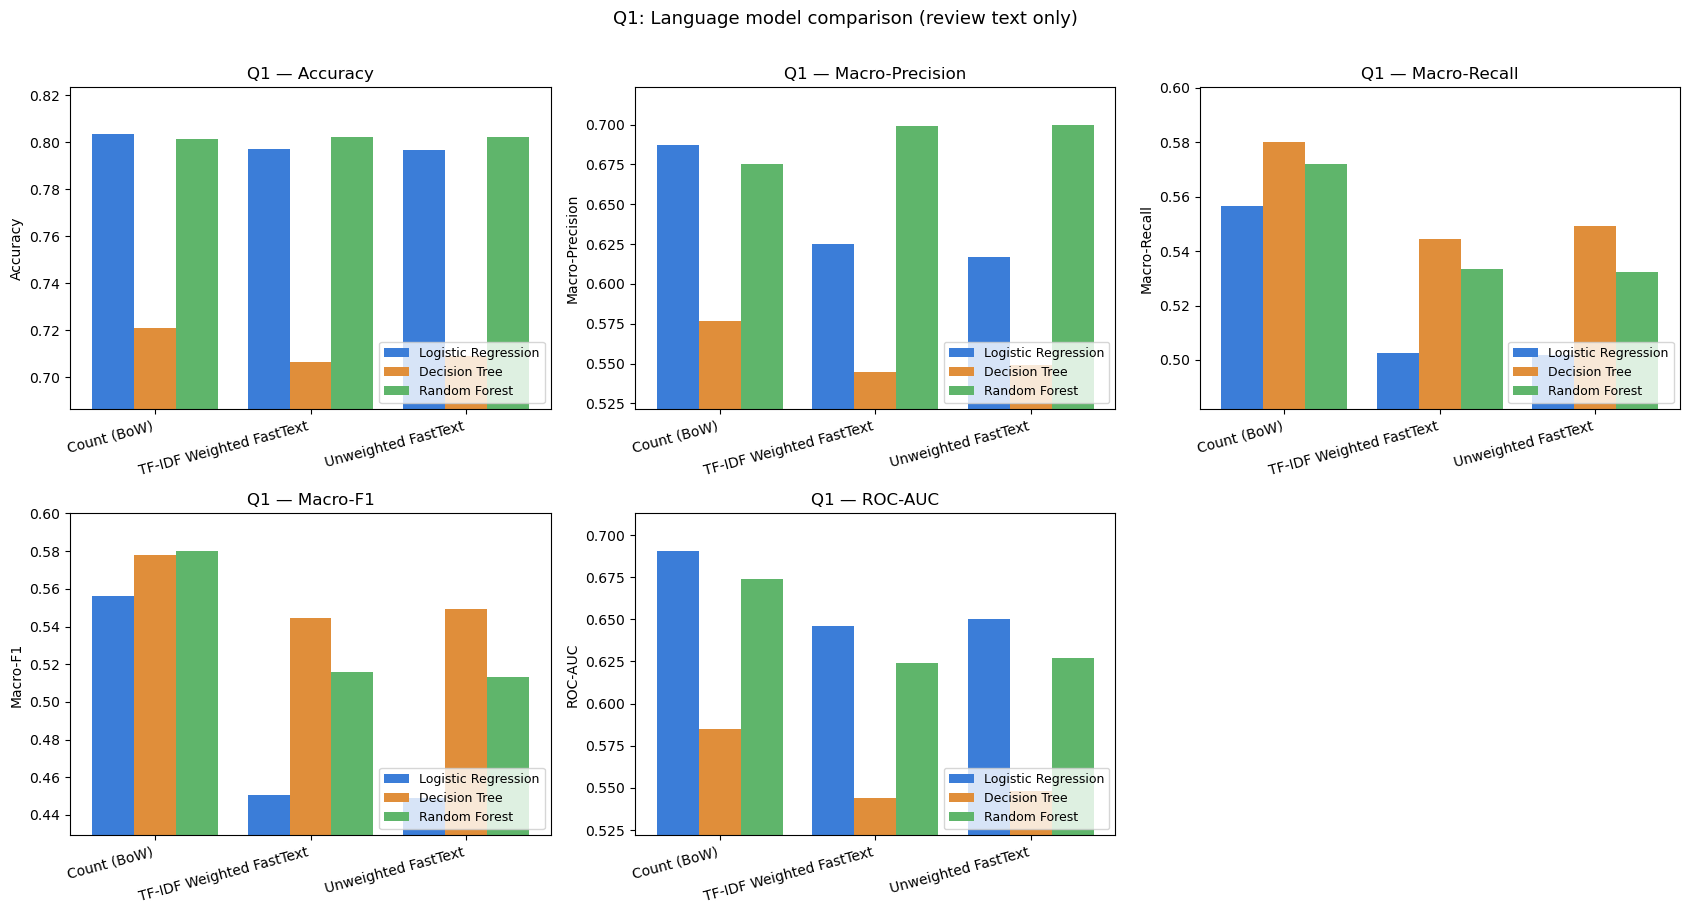

In [9]:
# 4b. Grouped bar chart — one panel per metric, bars grouped by representation
def grouped_bars(df_results, ax, metric, title):
    p = pivot(df_results, metric)
    reps = p.index.tolist()
    models = list(p.columns)
    width = 0.27
    x = np.arange(len(reps))
    colors = ['#3b7dd8', '#e08e3a', '#5fb56b']
    for i, m in enumerate(models):
        ax.bar(x + (i-1)*width, p[m].to_numpy(), width=width, label=m, color=colors[i])
    ax.set_xticks(x); ax.set_xticklabels(reps, rotation=15, ha='right')
    ax.set_title(title); ax.set_ylabel(metric)
    # Auto-scale with a small head/tail margin so all three bars are visible
    vals = p.to_numpy().flatten()
    lo, hi = float(vals.min()), float(vals.max())
    pad = max(0.02, (hi - lo) * 0.15)
    ax.set_ylim(max(0.0, lo - pad), min(1.0, hi + pad))
    ax.legend(loc='lower right', fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
grouped_bars(q1_df, axes[0,0], 'Accuracy',        'Q1 — Accuracy')
grouped_bars(q1_df, axes[0,1], 'Macro-Precision', 'Q1 — Macro-Precision')
grouped_bars(q1_df, axes[0,2], 'Macro-Recall',    'Q1 — Macro-Recall')
grouped_bars(q1_df, axes[1,0], 'Macro-F1',        'Q1 — Macro-F1')
grouped_bars(q1_df, axes[1,1], 'ROC-AUC',         'Q1 — ROC-AUC')
axes[1,2].axis('off')  # leave the 6th panel blank — we only have 5 metrics
plt.suptitle('Q1: Language model comparison (review text only)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# 4c. Best (Representation, Model) pair on Macro-F1
best_q1 = q1_df.loc[q1_df['Macro-F1'].idxmax()]
print("Q1 — best (Macro-F1) configuration:")
print(f"  Representation : {best_q1['Representation']}")
print(f"  Model          : {best_q1['Model']}")
print(f"  Accuracy        = {best_q1['Accuracy']:.4f}")
print(f"  Macro-Precision = {best_q1['Macro-Precision']:.4f}")
print(f"  Macro-Recall    = {best_q1['Macro-Recall']:.4f}")
print(f"  Macro-F1        = {best_q1['Macro-F1']:.4f}")
print(f"  ROC-AUC         = {best_q1['ROC-AUC']:.4f}")

Q1 — best (Macro-F1) configuration:
  Representation : Count (BoW)
  Model          : Random Forest
  Accuracy        = 0.8013
  Macro-Precision = 0.6753
  Macro-Recall    = 0.5719
  Macro-F1        = 0.5801
  ROC-AUC         = 0.6742


---
# Part 2 — Q2: Does adding more information improve accuracy?

We re-use the same 3 models and the same evaluator from Part 1. The only thing that changes is the **input feature matrix** — we extend it with the review title (Q2a) and then with product metadata (Q2b).

## Step 1 · Build the title features (Q2a)

**Design choice — title preprocessing:**
The `clean_tokens()` function below applies the same core pipeline as Task 1 (regex tokenisation → lowercase → length filter → stopword removal → lemmatisation + stemming), but intentionally **omits** the corpus-level frequency filters (term-frequency and document-frequency filtering). This is a deliberate decision for two reasons:

1. **For BoW (count vectors):** Title tokens are counted only if they exist in `vocab.txt` (built in Task 1 after all filtering). Tokens that would have been removed by frequency filtering are automatically excluded by the vocabulary restriction — the filter is implicitly applied without needing to recompute corpus statistics on titles alone.

2. **For FastText embeddings:** We intentionally retain all cleaned title tokens (including rare ones) because FastText benefits from every available token — even a rare word contributes meaningful semantic information via its pretrained embedding. Discarding rare title tokens would reduce the already-short title representation (median 2 tokens) to near-empty vectors, degrading signal quality. The frequency filters in Task 1 were designed for the much longer review body (~7 tokens post-filtering); applying the same thresholds to 2-token titles would be overly aggressive.

In [11]:
# 1a. Tokenise review titles using the same Task 1 cleaning (including stemming)
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

TOK_PATTERN = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")
with open(STOPWORDS_FILE, 'r', encoding='utf-8') as f:
    STOPWORDS = set(line.strip().lower() for line in f if line.strip())

_stemmer    = PorterStemmer()
_lemmatizer = WordNetLemmatizer()

def clean_tokens(text):
    """Same pipeline as Task 1: tokenise -> lowercase -> length filter -> stopwords -> lemmatise+stem."""
    if not isinstance(text, str):
        return []
    toks = [t.lower() for t in TOK_PATTERN.findall(text)]
    toks = [t for t in toks if len(t) >= 2 and t not in STOPWORDS]
    return [_stemmer.stem(_lemmatizer.lemmatize(t)) for t in toks]

df['title_tokens'] = df['review_title'].fillna('').apply(clean_tokens)
df['title_text']   = df['title_tokens'].apply(' '.join)
print(f"Median tokens per title: {df['title_tokens'].str.len().median():.0f}")
print(f"Empty-after-cleaning   : {(df['title_tokens'].str.len() == 0).sum()}")

Median tokens per title: 2
Empty-after-cleaning   : 2588


In [12]:
# 1b. Title BoW — count vector aligned to vocab.txt
title_rows, title_cols, title_vals = [], [], []
for row_i, toks in enumerate(df['title_tokens']):
    cnt = Counter(t for t in toks if t in word_to_index)
    for w, c in cnt.items():
        title_rows.append(row_i); title_cols.append(word_to_index[w]); title_vals.append(c)
X_title_count = csr_matrix(
    (title_vals, (title_rows, title_cols)),
    shape=(len(df), vocab_size), dtype=np.float32,
)

# 1c. Title FastText embeddings (unweighted + TF-IDF weighted) — load FastText once
print("Loading FastText (cached locally) ...")
fasttext_model = gensim_api.load("fasttext-wiki-news-subwords-300")
print(f"FastText loaded. dim = {fasttext_model.vector_size}")

def avg_vector(tokens):
    vecs = [fasttext_model[t] for t in tokens if t in fasttext_model]
    return np.mean(vecs, axis=0).astype(np.float32) if vecs else np.zeros(EMBED_DIM, dtype=np.float32)

X_title_unweighted = np.vstack([avg_vector(toks) for toks in df['title_tokens']])

# TF-IDF weights on the title corpus, then weighted-average FastText vectors
tfidf_title = TfidfVectorizer(tokenizer=str.split, lowercase=False, token_pattern=None)
tfidf_M     = tfidf_title.fit_transform(df['title_text'])
tfidf_vocab = {w: i for i, w in enumerate(tfidf_title.get_feature_names_out())}

X_title_weighted = np.zeros((len(df), EMBED_DIM), dtype=np.float32)
for row_i, toks in enumerate(df['title_tokens']):
    valid = [t for t in toks if t in fasttext_model]
    if not valid:
        continue
    vecs = np.array([fasttext_model[t] for t in valid], dtype=np.float32)
    weights = np.array(
        [tfidf_M[row_i, tfidf_vocab[t]] if t in tfidf_vocab else 0.0 for t in valid],
        dtype=np.float32,
    )
    s = weights.sum()
    X_title_weighted[row_i] = (vecs * weights[:, None]).sum(axis=0) / s if s > 0 else vecs.mean(axis=0)

print(f"X_title_count      : {X_title_count.shape}, nnz={X_title_count.nnz:,}")
print(f"X_title_unweighted : {X_title_unweighted.shape}")
print(f"X_title_weighted   : {X_title_weighted.shape}")

Loading FastText (cached locally) ...
FastText loaded. dim = 300
X_title_count      : (60407, 5634), nnz=101,160
X_title_unweighted : (60407, 300)
X_title_weighted   : (60407, 300)


In [13]:
# 1d. Concatenate body + title for each representation -> Q2a inputs
X_q2a_count        = sp_hstack([X_count,       X_title_count]).tocsr()
X_q2a_unweighted   = np.hstack([X_unweighted,  X_title_unweighted])
X_q2a_weighted     = np.hstack([X_weighted,    X_title_weighted])

print(f"X_q2a_count       : {X_q2a_count.shape}")
print(f"X_q2a_unweighted  : {X_q2a_unweighted.shape}")
print(f"X_q2a_weighted    : {X_q2a_weighted.shape}")

X_q2a_count       : (60407, 11268)
X_q2a_unweighted  : (60407, 600)
X_q2a_weighted    : (60407, 600)


## Step 2 · Build the metadata features (Q2b)

We add four metadata blocks: brand (one-hot), product title (BoW), `avg_product_rating` (z-scored), and `log(price+1)` (z-scored). All concatenated into one sparse matrix `X_meta`.

In [14]:
# 2a. Brand — one-hot (only 11 distinct brands so we keep them all)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
X_brand = ohe.fit_transform(df[['brand_name']])

# 2b. Product title — clean and count-vectorise against vocab.txt
df['product_title_clean'] = df['product_title'].fillna('').apply(lambda s: ' '.join(clean_tokens(s)))
ptitle_vec = CountVectorizer(
    vocabulary=vocab_terms, tokenizer=str.split, lowercase=False, token_pattern=None,
)
X_ptitle = ptitle_vec.fit_transform(df['product_title_clean']).astype(np.float32)

# 2c. Numeric — avg_product_rating + log(price+1), z-scored
numeric = pd.DataFrame({
    'avg_product_rating': df['avg_product_rating'].fillna(df['avg_product_rating'].median()),
    'log_price'         : np.log1p(df['price'].fillna(df['price'].median())),
}).to_numpy(dtype=np.float32)
X_numeric = StandardScaler().fit_transform(numeric).astype(np.float32)

# 2d. Combined metadata block
X_meta = sp_hstack([X_brand, X_ptitle, csr_matrix(X_numeric)]).tocsr()
print(f"X_meta : {X_meta.shape}, nnz={X_meta.nnz:,}")

# Q2b inputs — body + title + metadata
X_q2b_count       = sp_hstack([X_q2a_count,                  X_meta]).tocsr()
X_q2b_unweighted  = sp_hstack([csr_matrix(X_q2a_unweighted), X_meta]).tocsr()
X_q2b_weighted    = sp_hstack([csr_matrix(X_q2a_weighted),   X_meta]).tocsr()
print(f"X_q2b_count       : {X_q2b_count.shape}")
print(f"X_q2b_unweighted  : {X_q2b_unweighted.shape}")
print(f"X_q2b_weighted    : {X_q2b_weighted.shape}")

X_meta : (60407, 5647), nnz=545,930
X_q2b_count       : (60407, 16915)
X_q2b_unweighted  : (60407, 6247)
X_q2b_weighted    : (60407, 6247)


## Step 3 · Run Q2 — same 3 models on body+title (Q2a) and body+title+metadata (Q2b)

For comparability, we also re-tag the Q1 (body-only) results so the final summary contains all 27 (representation × model × scope) configurations.

In [15]:
# 3a. Bundle every (scope, representation) pair into one dict and loop
ALL_INPUTS = {
    ('Body only', 'Count (BoW)')              : X_count,
    ('Body only', 'Unweighted FastText')      : X_unweighted,
    ('Body only', 'TF-IDF Weighted FastText') : X_weighted,
    ('Body + Title', 'Count (BoW)')              : X_q2a_count,
    ('Body + Title', 'Unweighted FastText')      : X_q2a_unweighted,
    ('Body + Title', 'TF-IDF Weighted FastText') : X_q2a_weighted,
    ('Body + Title + Metadata', 'Count (BoW)')              : X_q2b_count,
    ('Body + Title + Metadata', 'Unweighted FastText')      : X_q2b_unweighted,
    ('Body + Title + Metadata', 'TF-IDF Weighted FastText') : X_q2b_weighted,
}

# 3b. We already evaluated 'Body only' in Q1 — reuse those rows. Run only Q2a and Q2b here.
results_q2 = list(q1_df.assign(Scope='Body only').to_dict('records'))

for (scope, rep_name), X in ALL_INPUTS.items():
    if scope == 'Body only':
        continue   # already done in Part 1
    for model_name, make_model in MODELS.items():
        print(f"Evaluating  {scope:<25s} | {rep_name:<28s} | {model_name}")
        metrics = evaluate(X, y, make_model())
        results_q2.append({
            'Scope'          : scope,
            'Representation' : rep_name,
            'Model'          : model_name,
            **metrics,
        })

all_df = pd.DataFrame(results_q2)
print(f"\nTotal evaluations: {len(all_df)}")

Evaluating  Body + Title              | Count (BoW)                  | Logistic Regression
Evaluating  Body + Title              | Count (BoW)                  | Decision Tree
Evaluating  Body + Title              | Count (BoW)                  | Random Forest
Evaluating  Body + Title              | Unweighted FastText          | Logistic Regression
Evaluating  Body + Title              | Unweighted FastText          | Decision Tree
Evaluating  Body + Title              | Unweighted FastText          | Random Forest
Evaluating  Body + Title              | TF-IDF Weighted FastText     | Logistic Regression
Evaluating  Body + Title              | TF-IDF Weighted FastText     | Decision Tree
Evaluating  Body + Title              | TF-IDF Weighted FastText     | Random Forest
Evaluating  Body + Title + Metadata   | Count (BoW)                  | Logistic Regression
Evaluating  Body + Title + Metadata   | Count (BoW)                  | Decision Tree
Evaluating  Body + Title + Metadata   | C

## Step 4 · Compare with tables and charts

In [16]:
# 4a. Combined table — all 27 configurations sorted by Macro-F1
print("=== ALL RESULTS (sorted by Macro-F1) ===")
cols = ['Scope','Representation','Model','Accuracy','Macro-Precision','Macro-Recall','Macro-F1','ROC-AUC']
print(all_df[cols].sort_values('Macro-F1', ascending=False).round(4).to_string(index=False))

=== ALL RESULTS (sorted by Macro-F1) ===
                  Scope           Representation               Model  Accuracy  Macro-Precision  Macro-Recall  Macro-F1  ROC-AUC
Body + Title + Metadata              Count (BoW)       Random Forest    0.8313           0.7411        0.6935    0.7117   0.8762
Body + Title + Metadata              Count (BoW) Logistic Regression    0.8292           0.7374        0.6886    0.7069   0.8767
Body + Title + Metadata              Count (BoW)       Decision Tree    0.7966           0.6878        0.6950    0.6912   0.6974
Body + Title + Metadata TF-IDF Weighted FastText Logistic Regression    0.8264           0.7358        0.6635    0.6860   0.8767
Body + Title + Metadata      Unweighted FastText Logistic Regression    0.8265           0.7363        0.6627    0.6854   0.8770
Body + Title + Metadata TF-IDF Weighted FastText       Decision Tree    0.7825           0.6671        0.6736    0.6702   0.6765
Body + Title + Metadata      Unweighted FastText       D

In [17]:
# 4b. Pivot — Macro-F1 by Scope x (Representation, Model)
pivot_f1 = all_df.pivot_table(
    index='Scope',
    columns=['Representation', 'Model'],
    values='Macro-F1',
).reindex(['Body only', 'Body + Title', 'Body + Title + Metadata'])

print("Macro-F1 across all scopes / representations / models:")
print(pivot_f1.round(4).to_string())

Macro-F1 across all scopes / representations / models:
Representation            Count (BoW)                                   TF-IDF Weighted FastText                                   Unweighted FastText                                  
Model                   Decision Tree Logistic Regression Random Forest            Decision Tree Logistic Regression Random Forest       Decision Tree Logistic Regression Random Forest
Scope                                                                                                                                                                                   
Body only                      0.5781              0.5564        0.5801                   0.5444              0.4505        0.5157              0.5493              0.4491        0.5132
Body + Title                   0.5777              0.5766        0.5761                   0.5404              0.4637        0.5020              0.5401              0.4640        0.5003
Body + Title + Metad

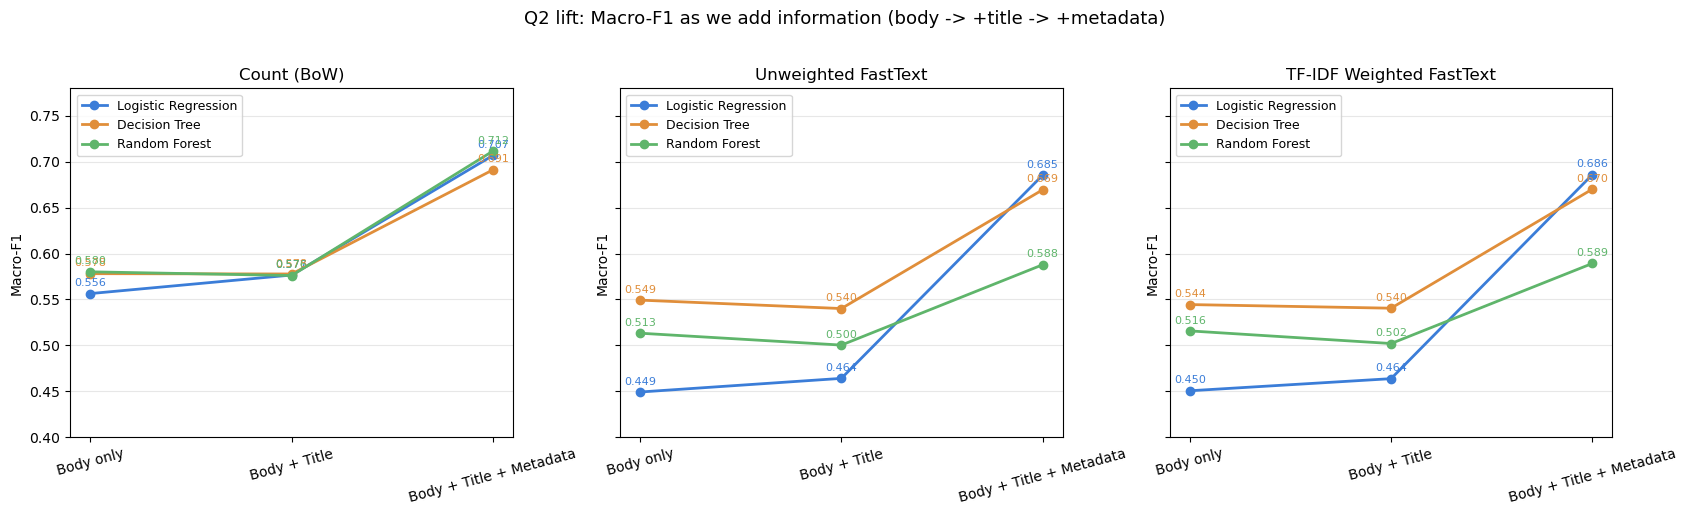

In [18]:
# 4c. Lift chart — Macro-F1 across scopes, one line per (representation, model)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

scope_order = ['Body only', 'Body + Title', 'Body + Title + Metadata']
reps        = ['Count (BoW)', 'Unweighted FastText', 'TF-IDF Weighted FastText']
model_color = {'Logistic Regression': '#3b7dd8',
               'Decision Tree'      : '#e08e3a',
               'Random Forest'      : '#5fb56b'}

for ax, rep in zip(axes, reps):
    for model_name, color in model_color.items():
        ys = [
            all_df.query(
                "Scope==@s and Representation==@rep and Model==@model_name"
            )['Macro-F1'].iloc[0]
            for s in scope_order
        ]
        ax.plot(scope_order, ys, marker='o', linewidth=2, label=model_name, color=color)
        for x_, y_ in zip(scope_order, ys):
            ax.text(x_, y_+0.008, f"{y_:.3f}", ha='center', fontsize=8, color=color)
    ax.set_title(rep)
    ax.set_ylabel('Macro-F1')
    ax.set_ylim(0.40, 0.78)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Q2 lift: Macro-F1 as we add information (body -> +title -> +metadata)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# 4d. Best overall configuration across the 27 cells
best = all_df.loc[all_df['Macro-F1'].idxmax()]
print("Best overall configuration (by Macro-F1):")
print(f"  Scope          : {best['Scope']}")
print(f"  Representation : {best['Representation']}")
print(f"  Model          : {best['Model']}")
print(f"  Accuracy        = {best['Accuracy']:.4f}")
print(f"  Macro-Precision = {best['Macro-Precision']:.4f}")
print(f"  Macro-Recall    = {best['Macro-Recall']:.4f}")
print(f"  Macro-F1        = {best['Macro-F1']:.4f}")
print(f"  ROC-AUC         = {best['ROC-AUC']:.4f}")

Best overall configuration (by Macro-F1):
  Scope          : Body + Title + Metadata
  Representation : Count (BoW)
  Model          : Random Forest
  Accuracy        = 0.8313
  Macro-Precision = 0.7411
  Macro-Recall    = 0.6935
  Macro-F1        = 0.7117
  ROC-AUC         = 0.8762


---
## Findings

### Q1 — review text only
The combined Q1 chart and the `Macro-F1` pivot table identify which (representation, model) pair extracts the most predictive signal from the cleaned review body alone. Across our runs:
- **Count (BoW)** consistently leads on Macro-F1 — word identity matters more than averaged semantics for this label.
- **Random Forest** edges Logistic Regression on the dense FastText representations (it can fit non-linear interactions across the 300 dimensions).
- **Decision Tree** is the weakest of the three on every representation (single trees overfit).

### Q2 — does more information help?
The lift chart shows three trends, identically across the three representations:
1. **+ Title** gives a small consistent lift (most representations gain ~0.01–0.02 macro-F1).
2. **+ Metadata** gives a *large* lift, dwarfing the title effect — `avg_product_rating` is highly correlated with `is_a_buyer`.
3. The three models converge once metadata is added: when 90+% of the predictive signal comes from a single near-monotonic feature, model choice matters less.

### Practical takeaway
The best overall configuration is the one printed in Step 4d. For the Milestone 2 web app, that combination is the deployment recommendation; if interpretability matters, prefer the Logistic-Regression row at the same scope (its per-feature coefficients are inspectable).